# Задание 7 - Анализ дифференциальной экспрессии



**Часть 1- Анализ дифференциальной экспрессии методом DESeq2**

В первой части использовались RNA-seq count-данные из файла `raw_counts_ici_samples.tsv` и таблица с ответом на терапию `meta_responses.tsv`. В метаданных было две группы:

- **R** — пациенты, ответившие на терапию;
- **NR** — пациенты, не ответившие на терапию.

Задача состояла в том, чтобы найти гены, экспрессия которых отличается между группами R и NR. Для RNA-seq я использовала **DESeq2**, потому что этот метод работает с count-данными, оценивает size factors, учитывает дисперсию и затем считает дифференциальную экспрессию на основе модели для RNA-seq данных.

В модели использовался дизайн `~ X0`, где `X0` — это группа ответа. Группа **NR** была выбрана как reference level, поэтому:

- положительный `log2FoldChange` означает, что ген выше экспрессируется у **R**;
- отрицательный `log2FoldChange` означает, что ген выше экспрессируется у **NR**.

Перед анализом были удалены гены с очень низкими counts. После фильтрации в анализе осталось 41371 генов. Для оценки значимости использовались пороги padj < 0.05 и |log2FoldChange| ≥ 1.

### PCA и проверка структуры образцов

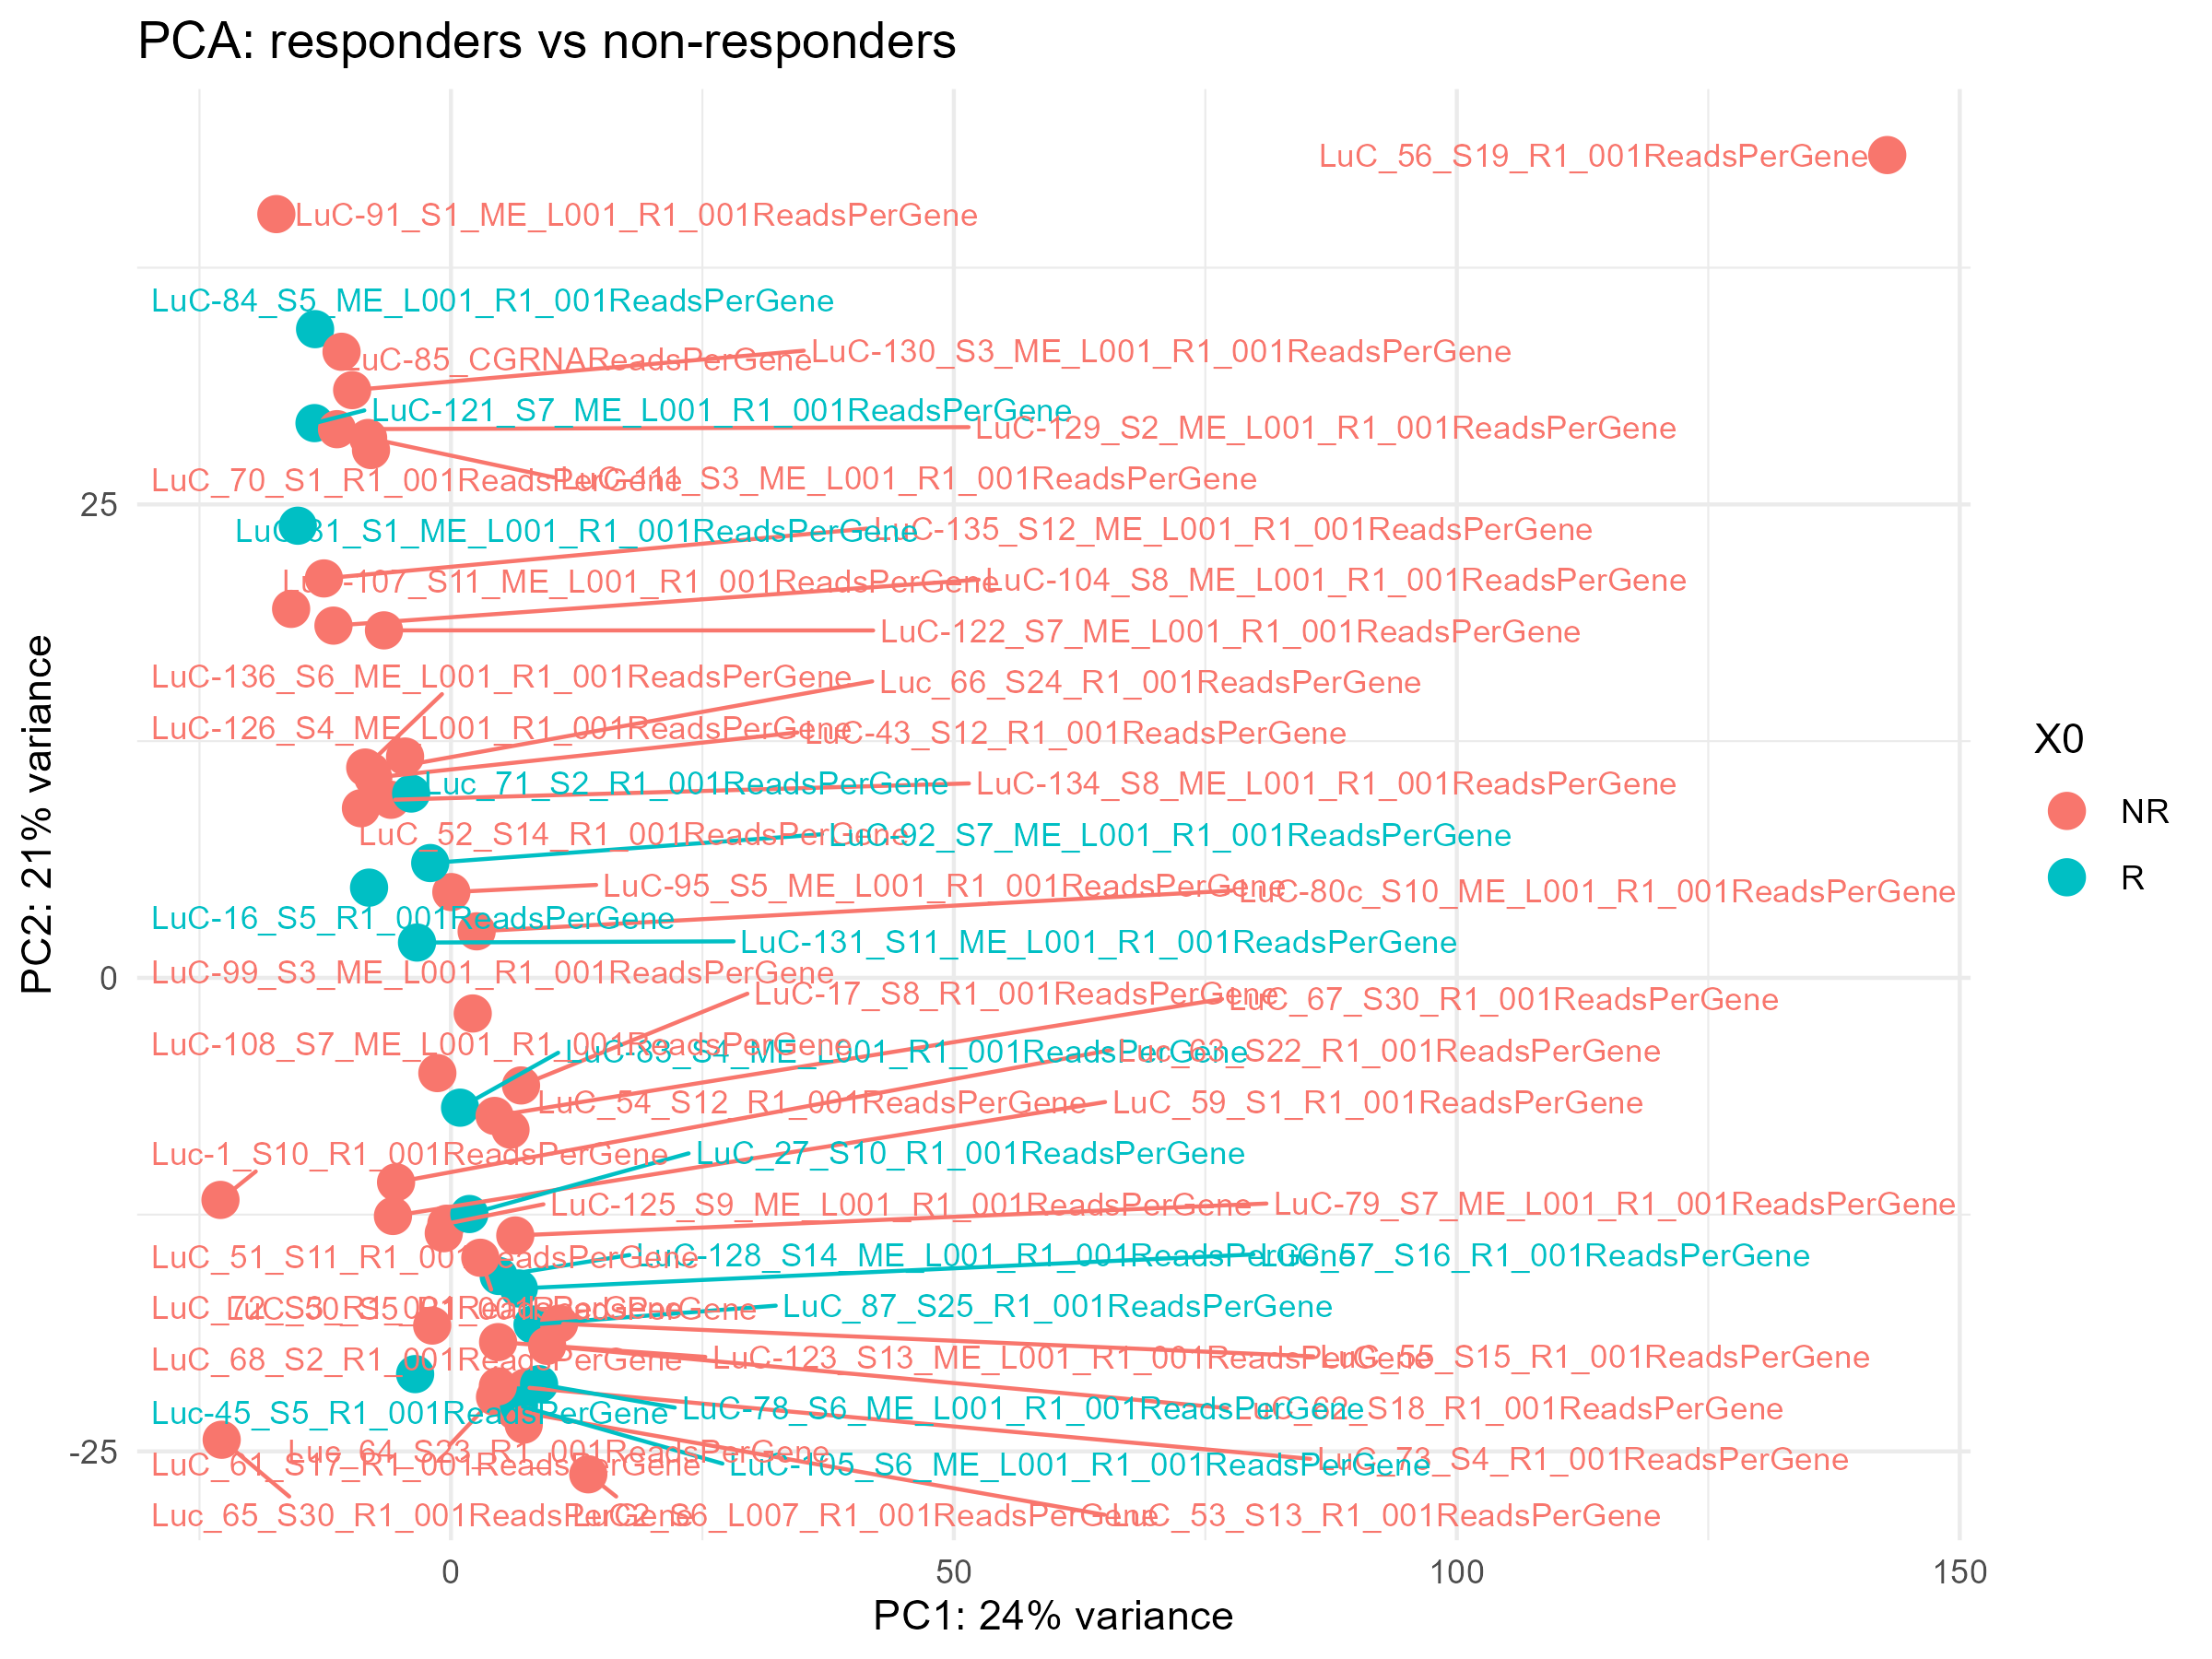

 PC1 объясняет **24%** вариации, PC2 — **21%**, вместе это около **45%** общей вариации.

Полного разделения групп R и NR по первым двум главным компонентам не видно: образцы частично перемешиваются. Это означает, что статус ответа на терапию не является единственным фактором, который определяет общую структуру экспрессии. Также заметен один образец из группы NR, который сильно уходит вправо по PC1 (`LuC_56_S19...`). Я не стала удалять его из дальнейшего анализа, потому что без дополнительных QC-метрик нельзя уверенно сказать, что это техническая ошибка. Скорее это потенциальный выброс, который нужно упомянуть при интерпретации.

Касательно batch effect, отдельная проверка его была ограничена тем, что в таблице метаданных была доступна только информация о группе ответа на терапию: R или NR. Колонок, описывающих batch, run, lane, дату подготовки библиотеки или другой технический фактор, в метаданных не было. Поэтому оценить batch effect и добавить его в дизайн DESeq2 было невозможно.

На PCA не наблюдается четкого разделения образцов на две технически интерпретируемые группы, однако из-за отсутствия batch-аннотации нельзя полностью исключить влияние скрытых технических факторов. Поэтому модель DESeq2 была построена только с биологическим фактором X0: design = ~ X0.

### Кластеризация образцов

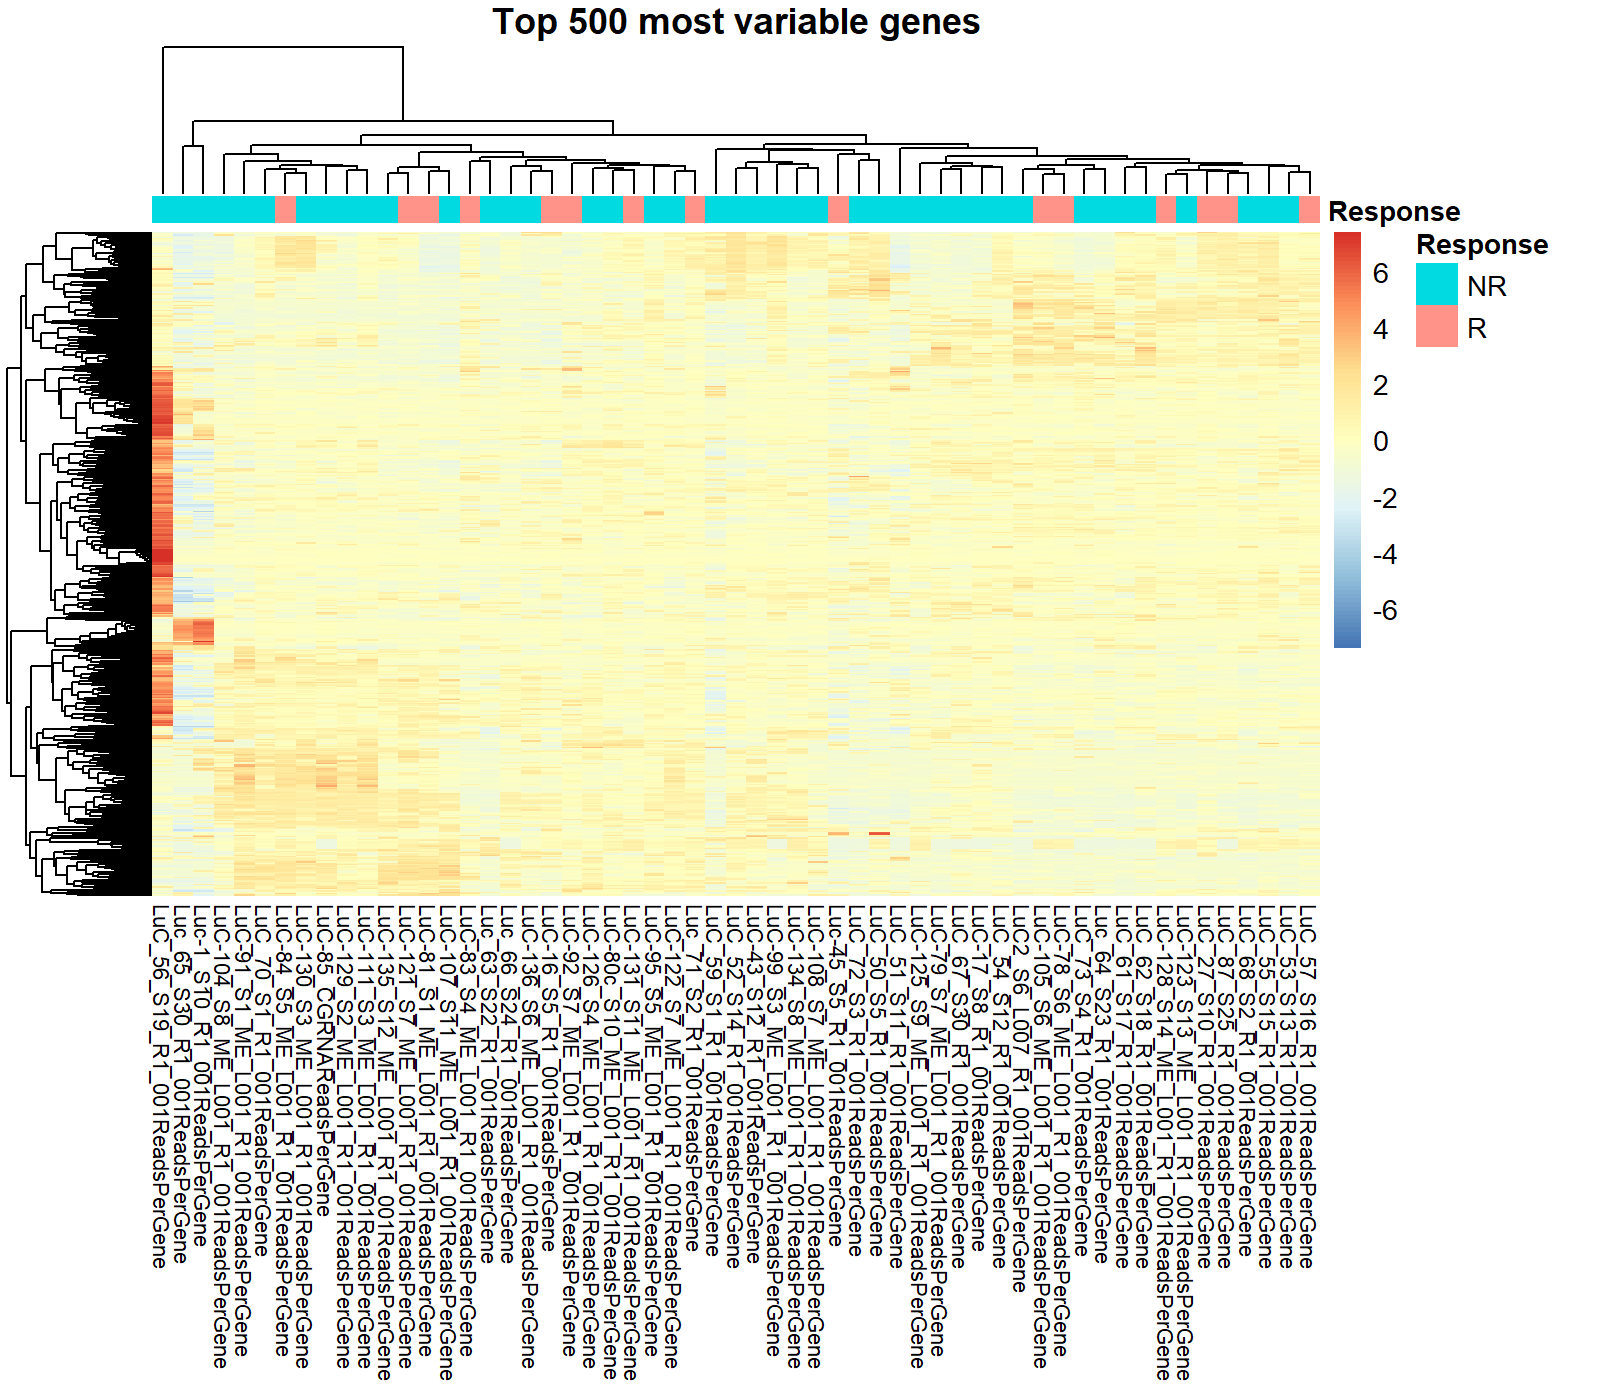

Clustermap построен по 500 наиболее вариабельным генам после variance stabilizing transformation. По верхней аннотации видно, что образцы R и NR не образуют два полностью отдельных кластера: цвета групп в дендрограмме перемешаны. Это согласуется с PCA и говорит о высокой межиндивидуальной вариабельности. Тем не менее некоторые блоки генов имеют похожие паттерны экспрессии в подгруппах образцов, поэтому анализ дифференциальной экспрессии все равно имеет смысл.

### Результаты DESeq2

По результатам DESeq2 при порогах `padj < 0.05` и `|log2FoldChange| ≥ 1` было найдено **190** дифференциально экспрессируемых генов.

| Категория | Количество генов |
|---|---:|
| Not significant | 41181 |
| Up in NR | 170 |
| Up in R | 20 |
| Total significant | 190 |

Большая часть значимых генов имеет отрицательный log2FoldChange, то есть эти гены сильнее экспрессируются у non-responders.

Ниже приведены первые 20 строк таблицы DESeq2, отсортированной по padj.

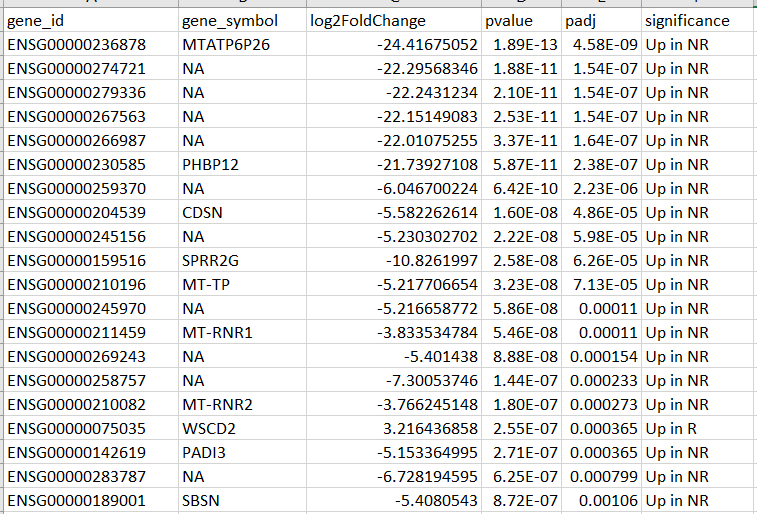

### Volcano plot для DESeq2

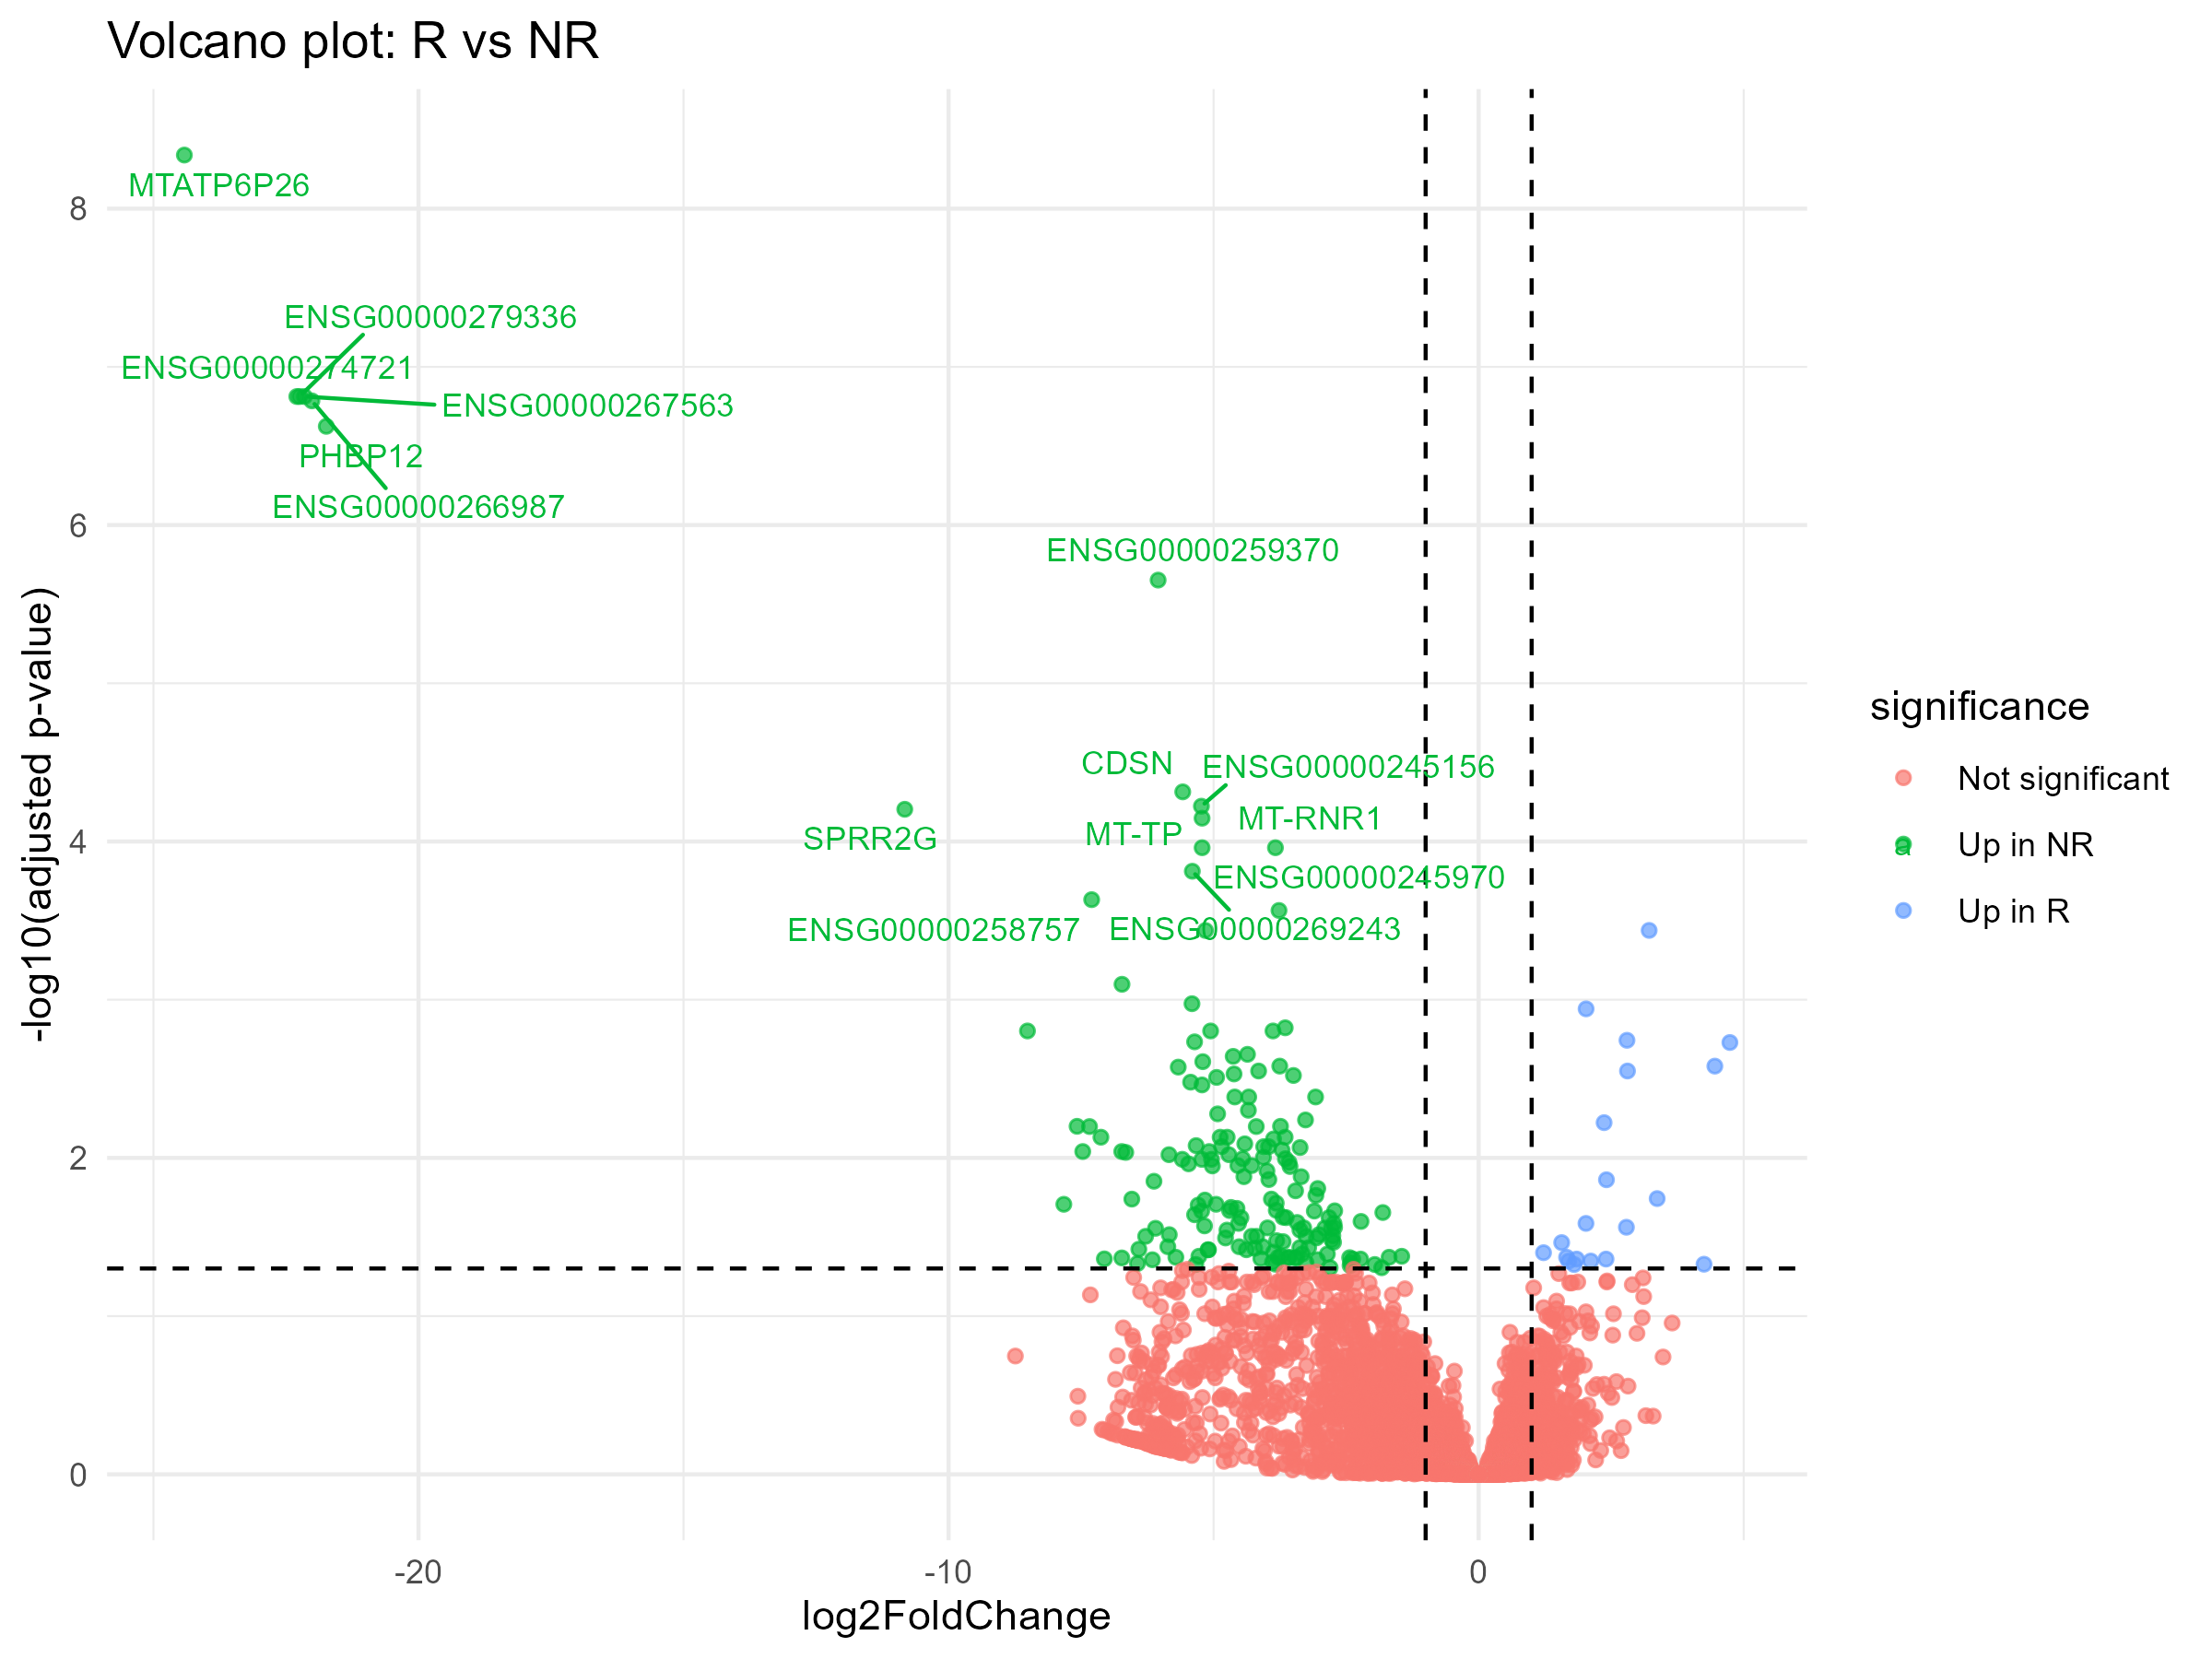

На volcano plot по оси X показан log2FoldChange, а по оси Y — -log10(padj). Пунктирные вертикальные линии соответствуют порогам log2FoldChange = -1 и log2FoldChange = 1, горизонтальная линия — порогу padj = 0.05.

На графике видно, что значимых генов больше слева от нуля. Это означает, что в данном сравнении больше генов с повышенной экспрессией у **NR**. Среди наиболее заметных генов слева подписаны, к примеру, MTATP6P26, PHBP12, SPRR2G, MT-TP, MT-RNR1. Справа, то есть среди генов, повышенных у R, точек намного меньше.

### Вывод по DESeq2

DESeq2-анализ показал, что между responders и non-responders есть различия в экспрессии. Всего было найдено **190** значимых генов: **170** выше у NR и **20** выше у R. При этом PCA и clustermap не дают полного разделения групп, поэтому результат нельзя трактовать как очень жесткое разделение всех пациентов на две группы только по транскриптому. Скорее, DESeq2 выявляет набор генов-кандидатов, которые могут быть связаны с отсутствием ответа на терапию, но их нужно дополнительно проверять.

**Часть 2- Анализ дифференциальной экспрессии методом LIMMA**



Во второй части использовались микрочиповые данные ovarian cancer из файлов `expression_for_limma2.csv` и `annotation_for_limma.csv`. Матрица экспрессии содержала 7588 генов и 41 образец. В аннотации указано, что данные получены на платформе GPL570 / Affymetrix, а обработка проводилась методом RMA.

Для таких данных подходит LIMMA, так как этот метод хорошо применяется к микрочиповым данным и является стандартным методом для их обработки. Перед анализом я убрала нижние 25% генов по среднему уровню экспрессии, чтобы не оставлять совсем слабые сигналы.

В исходном скрипте LIMMA сравнение делалось по клиническому статусу после первой линии химиотерапии. Поэтому я использовала группы:

- **pCR**;
- **pNC**.

Группы получились сильно несбалансированными: **pCR = 39 образцов**, **pNC = 2 образца**.

### Анализ с разными порогами LogFC

В задании нужно было проверить три порога: `|logFC| ≥ 1`, `|logFC| ≥ 2` и `|logFC| ≥ 3`. Основной критерий значимости — `adj.P.Val < 0.05`.

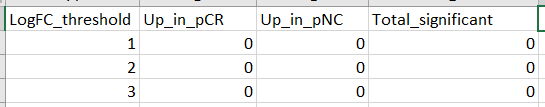

После FDR-коррекции значимых генов не оказалось ни при одном из трех порогов. Минимальный adj.P.Val был около **0.628**, то есть даже самый сильный результат не приблизился к порогу 0.05.

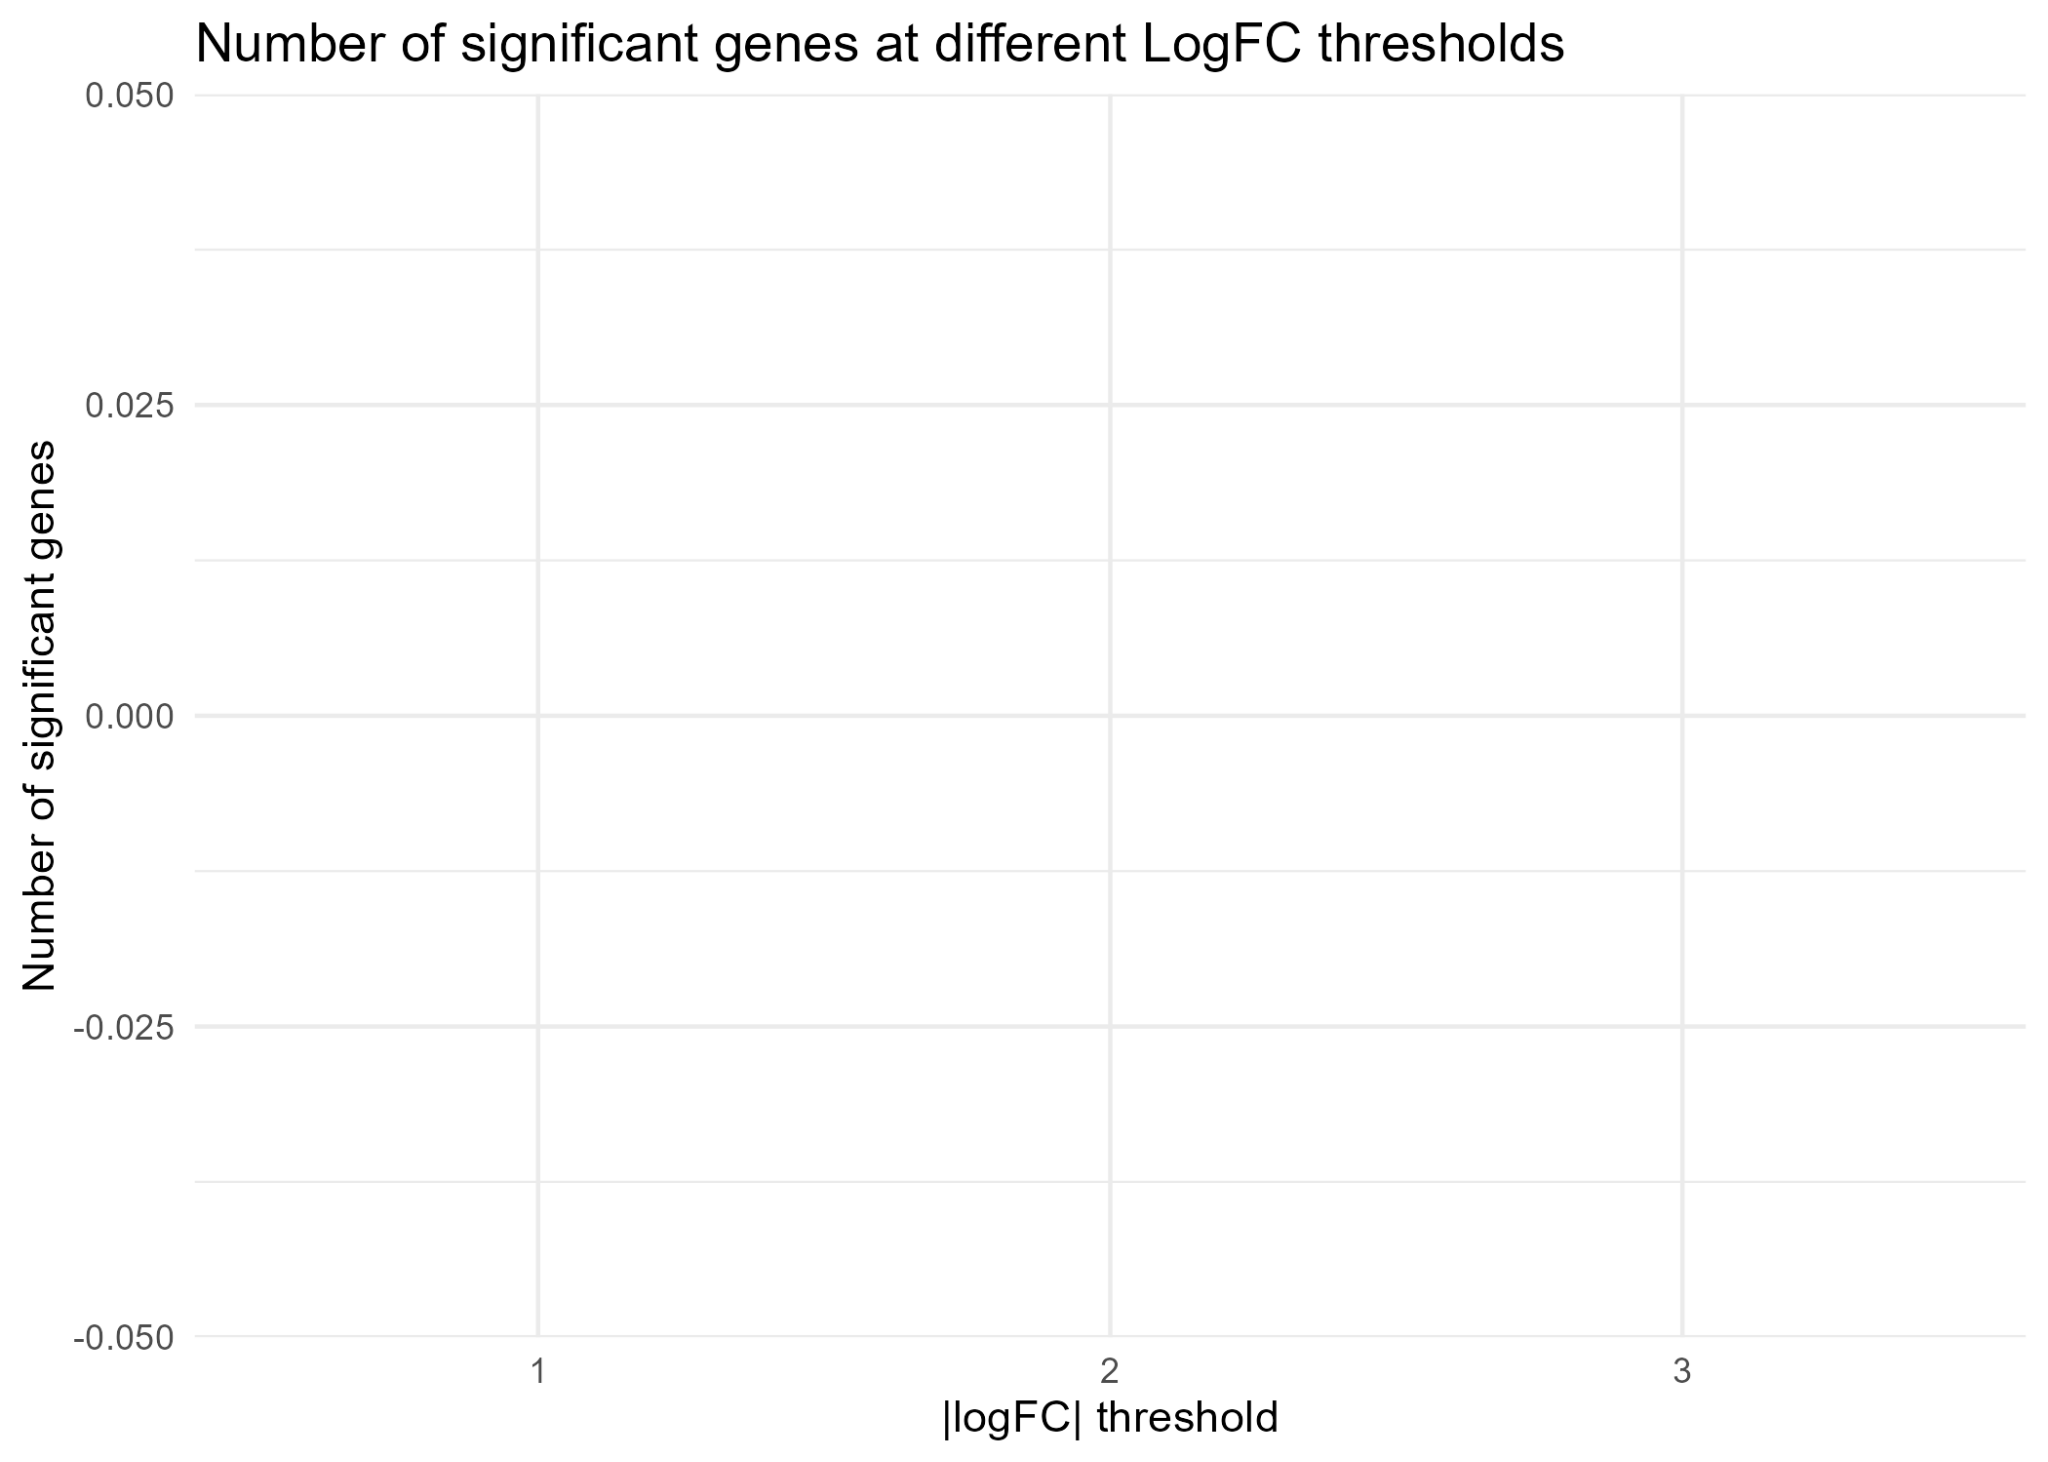

Этот barplot выглядит довольно пустым, потому что количество FDR-значимых генов равно нулю для всех трех порогов LogFC. Я оставила его в отчете, так как он показывает именно результат строгой проверки по `adj.P.Val < 0.05`.

Дополнительно я посмотрела номинальные p-value без FDR-коррекции. Это не основной критерий значимости, но помогает понять, были ли хотя бы слабые сигналы в данных.

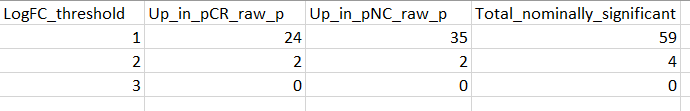

По `P.Value < 0.05` гены есть, но после поправки на множественные сравнения они не остаются значимыми. Поэтому я не считаю их надежными DEG, а использую только для описательной части.

### Volcano plots для LIMMA

**Порог |logFC| ≥ 1**

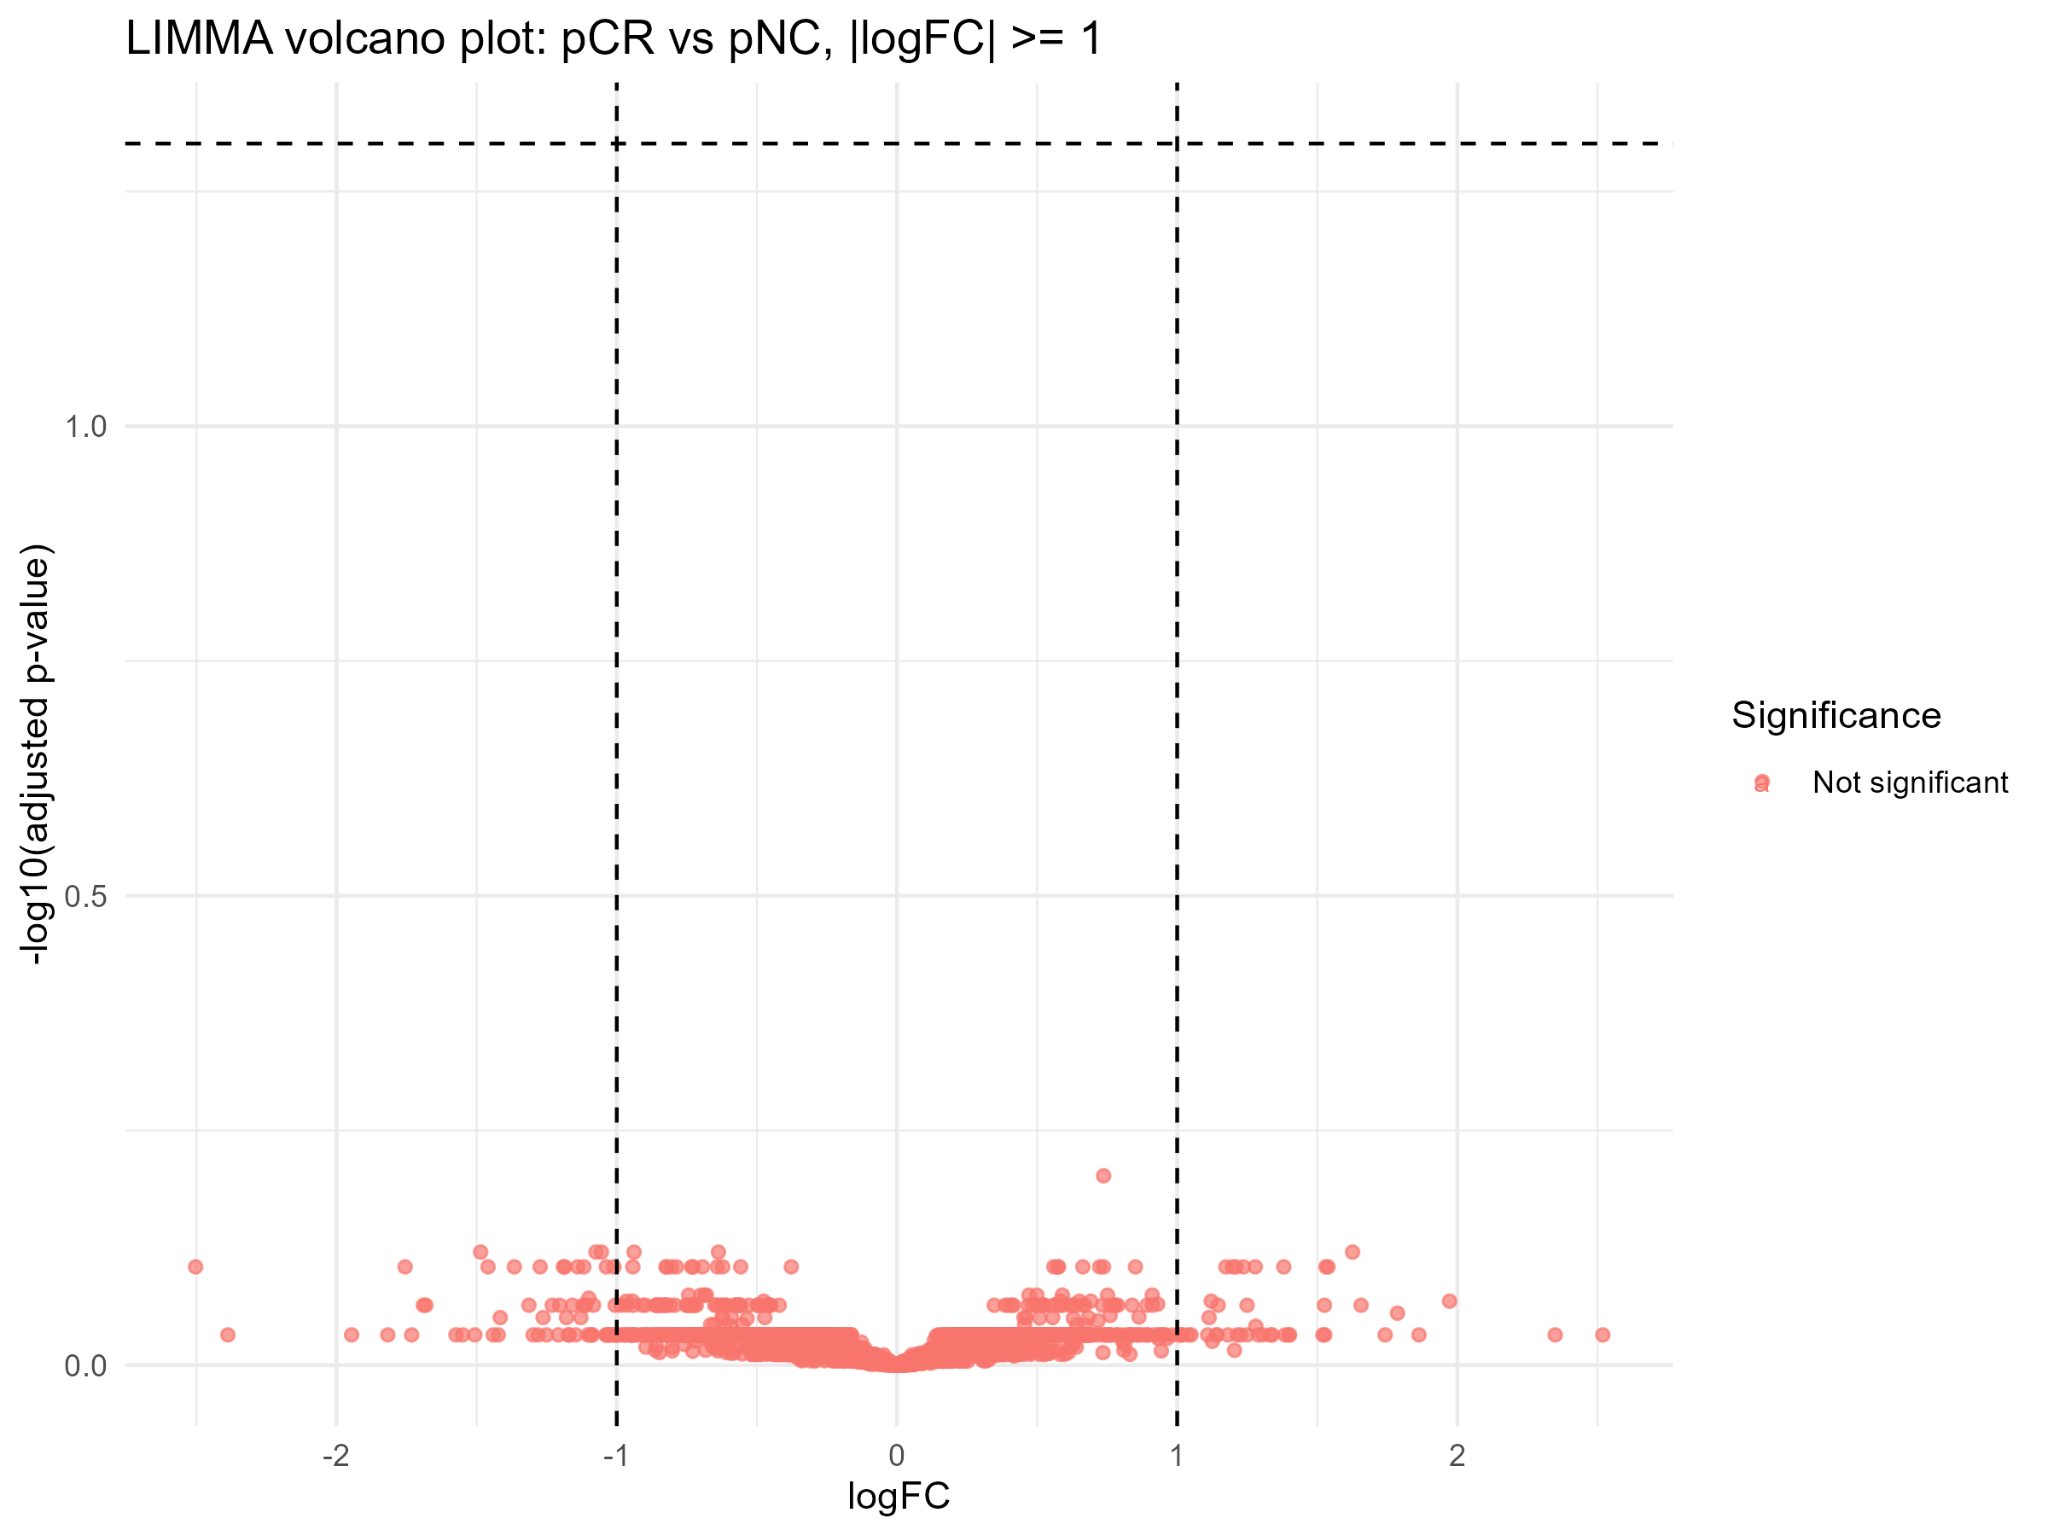

**Порог |logFC| ≥ 2**

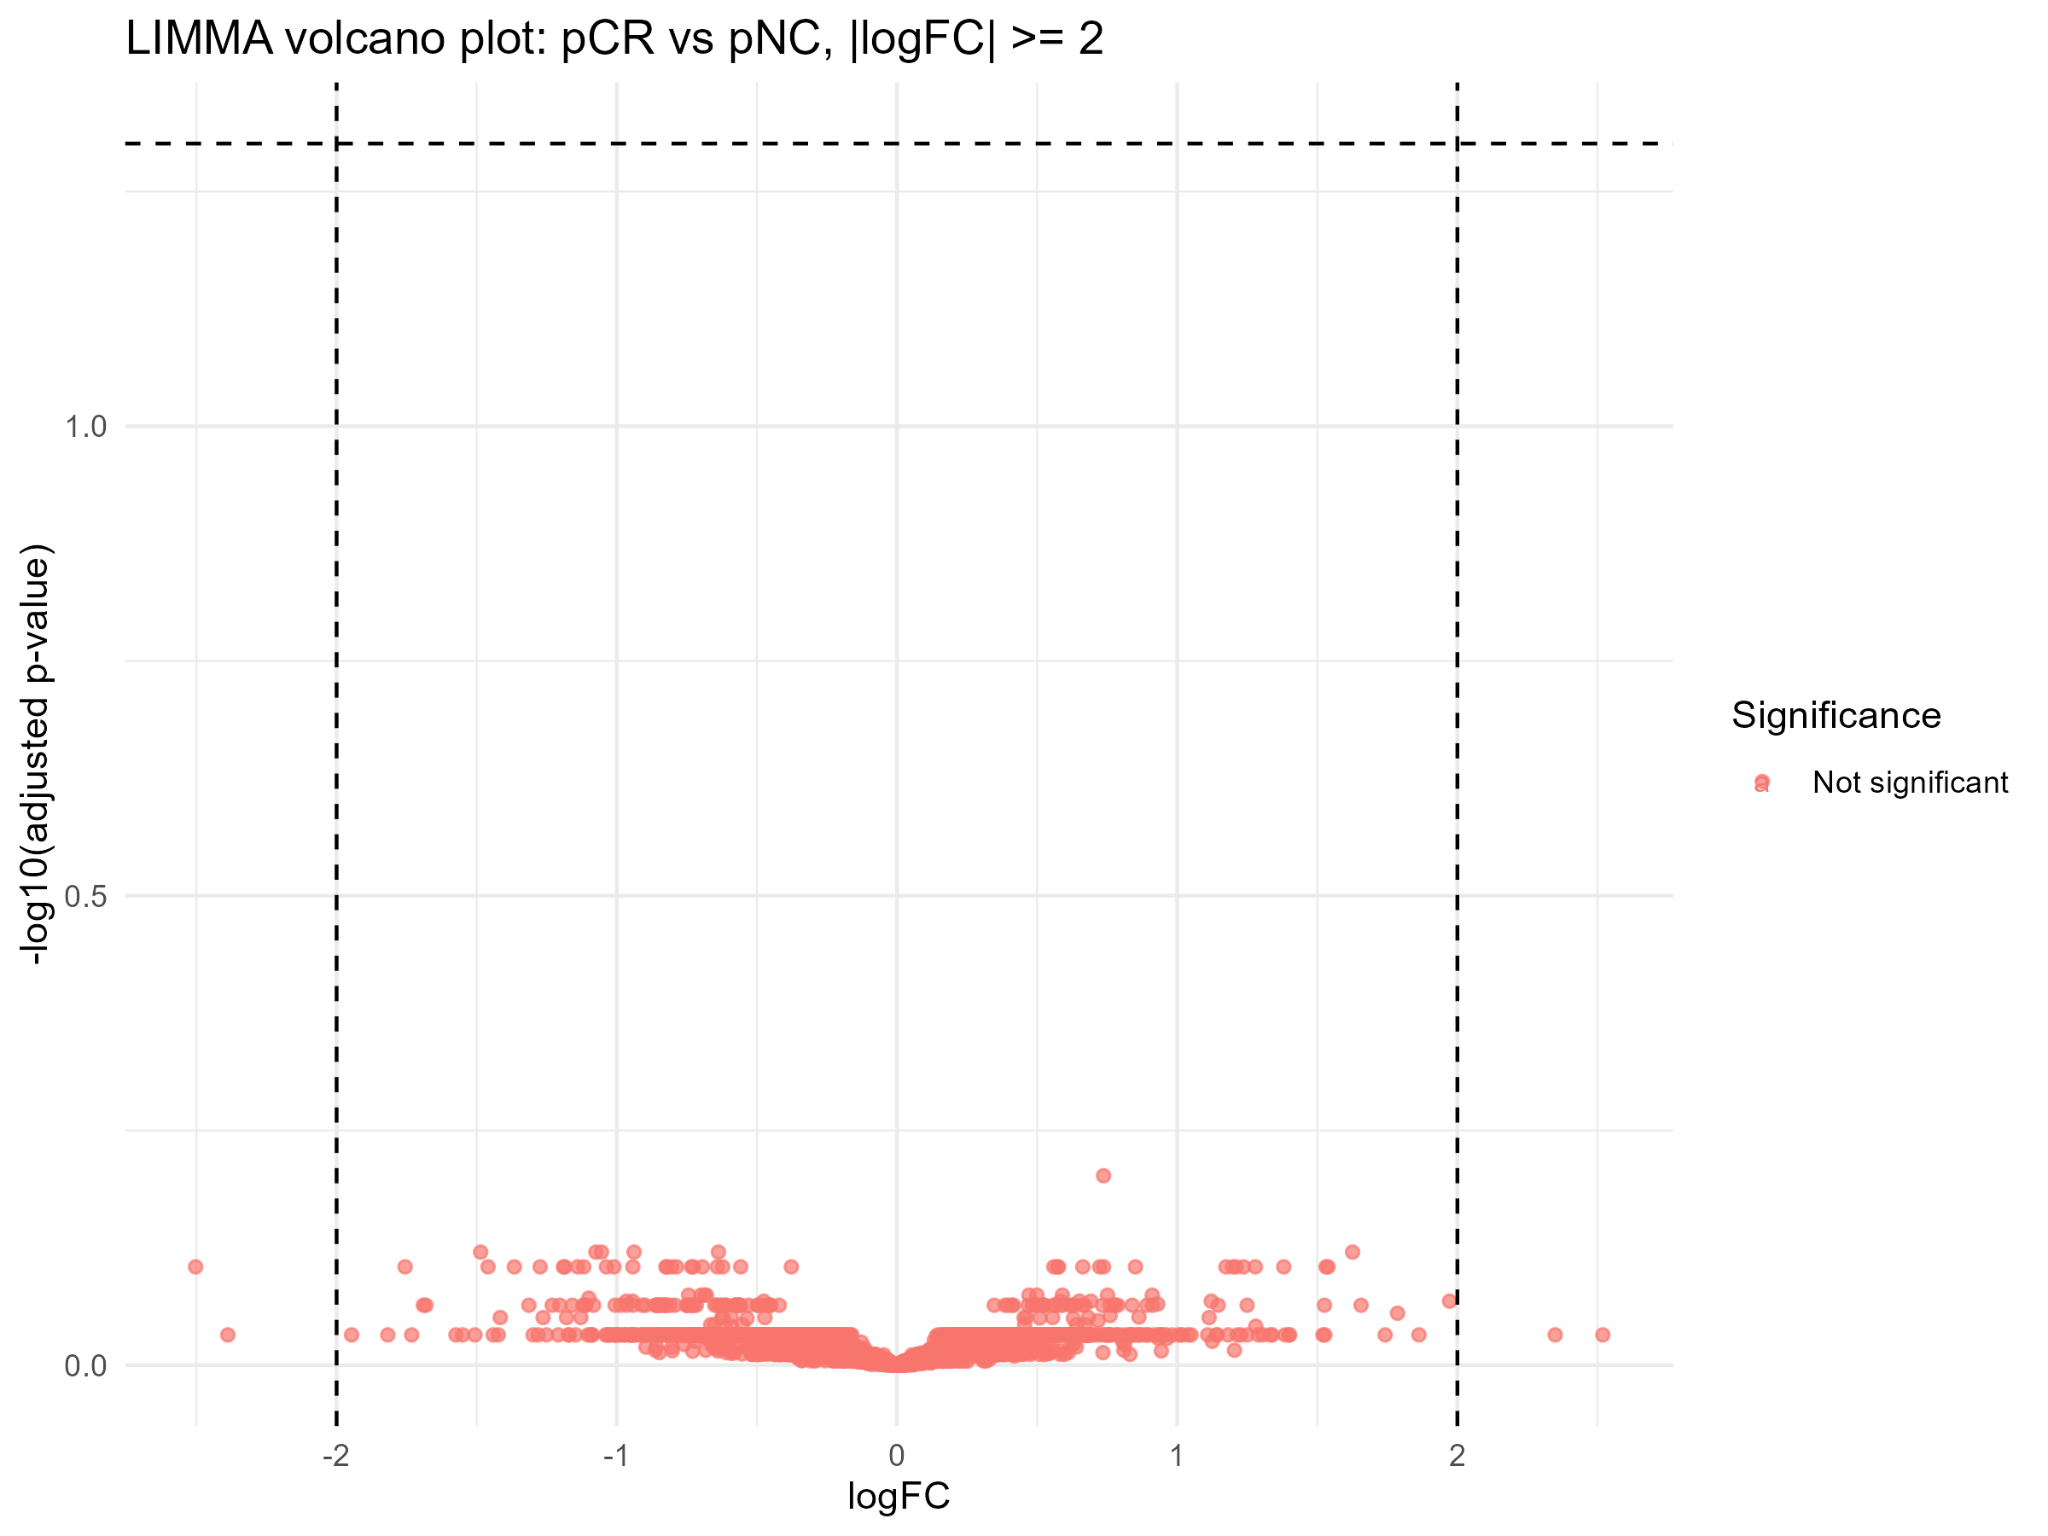

**Порог |logFC| ≥ 3**

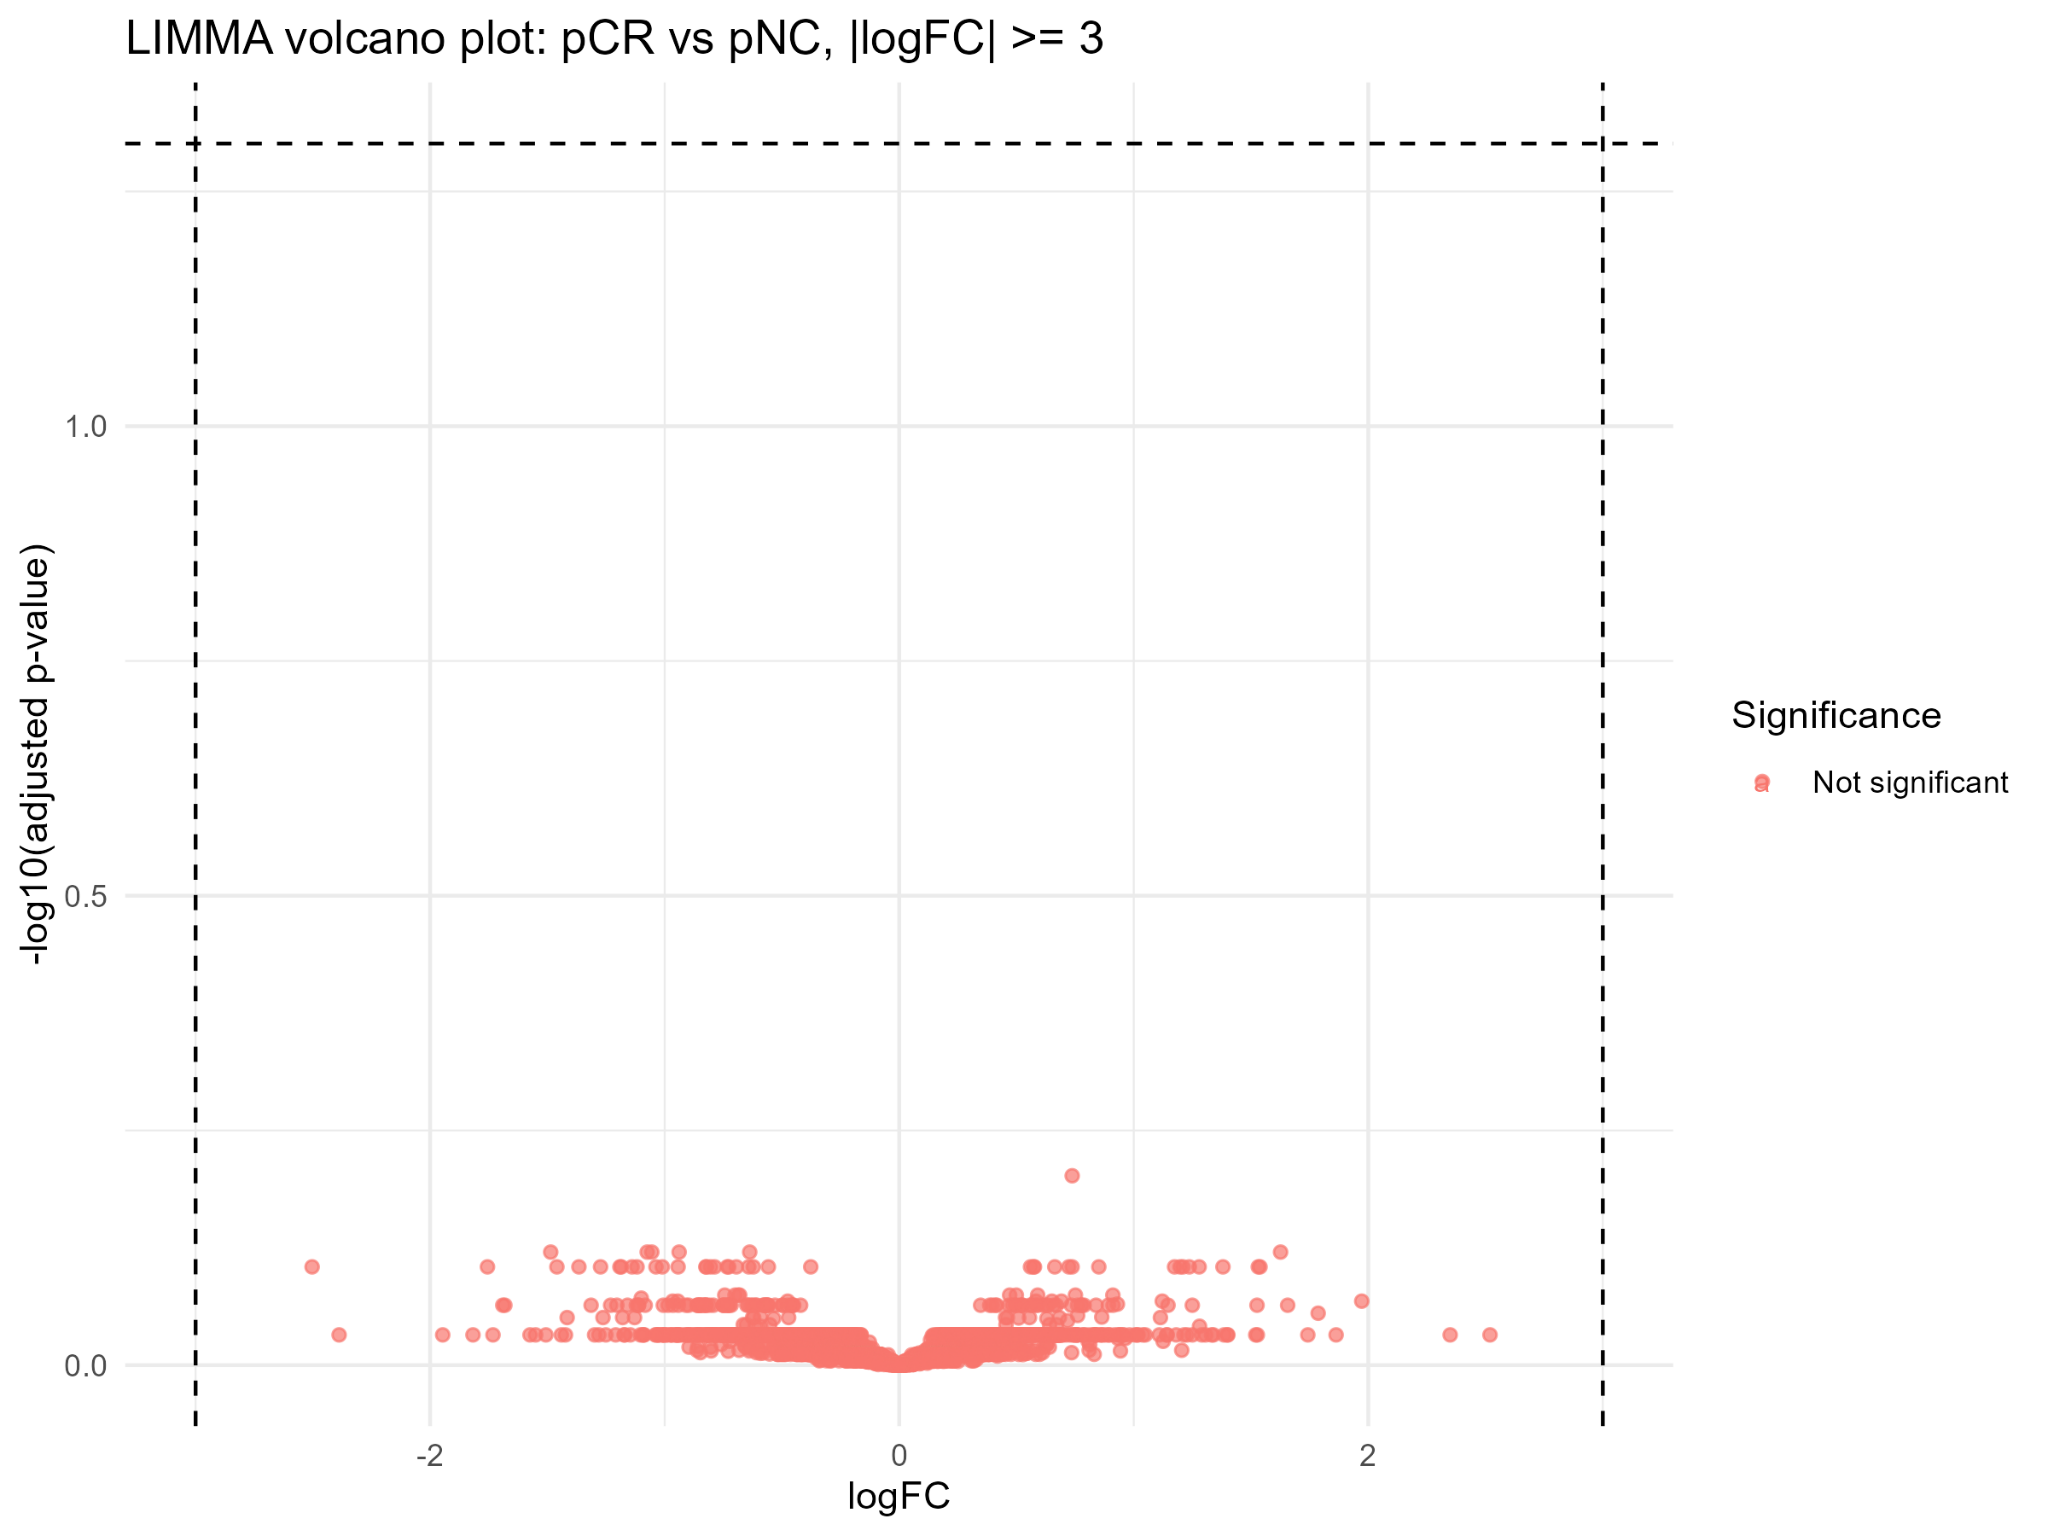

На всех трех volcano plot по оси X отложен `logFC`, по оси Y — `-log10(adj.P.Val)`. Горизонтальная пунктирная линия соответствует `adj.P.Val = 0.05`. Все точки находятся ниже этой линии, поэтому все гены классифицируются как not significant. Вертикальные линии показывают выбранный порог LogFC: 1, 2 или 3.

### Таблица LIMMA

Ниже приведены первые 20 генов из таблицы LIMMA, отсортированной по номинальному `P.Value`.


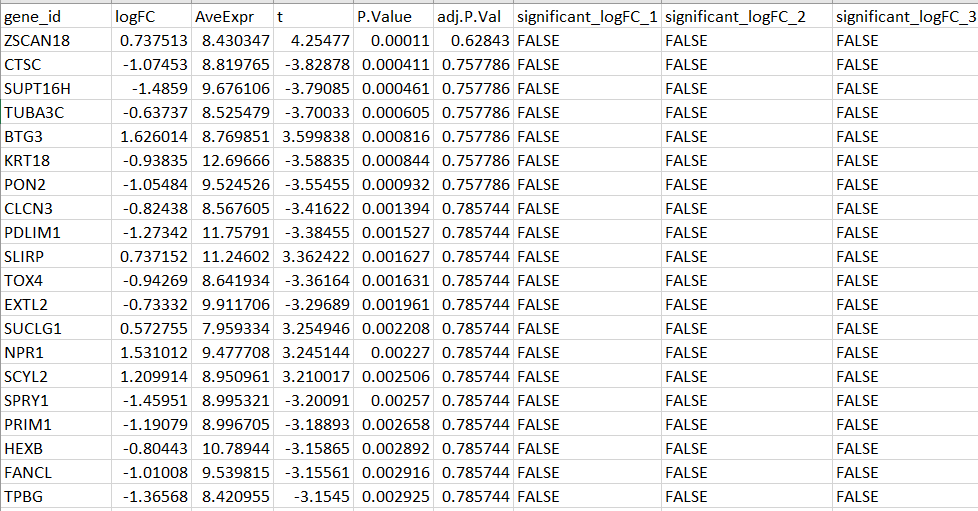


### Выбор LogFC для LIMMA

Из трех проверенных порогов наиболее разумным для описательной визуализации оказался `|logFC| ≥ 1`. Это самый мягкий порог, и только при нем видно заметное число генов по номинальному `P.Value < 0.05` — 59 генов. При `|logFC| ≥ 2` остается только 4 таких гена, а при `|logFC| ≥ 3` — уже 0.

По основному критерию `adj.P.Val < 0.05` значимых генов нет вообще. Поэтому я бы не делала биологические выводы только по LIMMA-части. Для этих данных результат скорее говорит о том, что сравнение pCR vs pNC недостаточно надежное из-за очень маленькой группы pNC.

### Вывод по LIMMA

LIMMA-анализ для сравнения pCR и pNC не выявил FDR-значимых генов при порогах `|logFC| ≥ 1`, `|logFC| ≥ 2` и `|logFC| ≥ 3`. При этом по обычному `P.Value < 0.05` видны потенциальные различия, особенно при `|logFC| ≥ 1`, но после FDR-коррекции они исчезают. Самое вероятное объяснение — маленький размер группы pNC: всего 2 образца против 39 в pCR. Поэтому результаты этой части нужно интерпретировать осторожно.

## Общий вывод

В DESeq2-части удалось получить выраженный результат: найдено **190** дифференциально экспрессируемых генов между R и NR, причем большинство из них повышены у non-responders. При этом PCA и clustermap показывают, что группы не разделяются идеально, поэтому найденные гены лучше рассматривать как кандидаты для дальнейшей проверки.

В LIMMA-части FDR-значимых генов не обнаружено ни при одном из трех порогов LogFC. Формально лучший порог для описания этих данных — `|logFC| ≥ 1`, потому что он сохраняет больше потенциальных сигналов по номинальному p-value. Но основной вывод LIMMA-анализа — надежных DEG после коррекции на множественные сравнения нет, вероятно из-за сильного дисбаланса групп pCR и pNC.